# Equity Cross-Sectional Signal Extraction Case Study

In [1]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import statsmodels.api as sm

from IPython.display import display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


## 1. Load data and perform a minimal global audit

In [2]:
path = "equity_cross_section_case.csv"
df_raw = pd.read_csv(path, parse_dates=["date"])

print("Raw shape:", df_raw.shape)
print("Date range:", df_raw["date"].min(), "to", df_raw["date"].max())
print("Assets:", df_raw["asset"].nunique())
print("Duplicate rows:", int(df_raw.duplicated().sum()))
print("Missing values by column:")
display(df_raw.isna().sum().to_frame("missing_count").T)
print("\nCross-sectional coverage by date:")
display(df_raw.groupby("date")["asset"].nunique().describe().to_frame("asset_count").T)

Raw shape: (46825, 15)
Date range: 2022-01-03 00:00:00 to 2023-12-29 00:00:00
Assets: 90
Duplicate rows: 25
Missing values by column:


,date,asset,sector,return_1d,value_signal,quality_signal,momentum_20d,short_term_reversal,beta_60d,liquidity_score,eps_revision_signal,size_score,market_return,market_vol_20d,macro_regime
missing_count,0,0,0,0,0,971,0,0,0,1398,2878,0,0,0,0



Cross-sectional coverage by date:


,count,mean,std,min,25%,50%,75%,max
asset_count,520.0,90.0,0.0,90.0,90.0,90.0,90.0,90.0


In [3]:
summary_table = pd.DataFrame({
    "min": df_raw.select_dtypes(include=np.number).min(),
    "max": df_raw.select_dtypes(include=np.number).max(),
    "mean": df_raw.select_dtypes(include=np.number).mean(),
    "std": df_raw.select_dtypes(include=np.number).std(),
})
display(summary_table)

,min,max,mean,std
return_1d,-0.075633,0.062254,-0.003944,0.015752
value_signal,-2.355555,3.248147,0.146763,0.736068
quality_signal,-2.273661,2.582216,0.086766,0.761830
momentum_20d,-2.738070,2.875608,-0.144380,0.592223
short_term_reversal,-2.275144,2.475939,0.059590,0.600062
beta_60d,0.329862,1.642842,1.003276,0.181369
liquidity_score,-1.852036,1.840743,-0.017078,0.494590
eps_revision_signal,-2.826627,2.778443,-0.055027,0.609601
size_score,-1.760267,1.860329,-0.074018,0.568817
market_return,-0.024244,0.019137,-0.002478,0.007335


***To be noted***: this is clearly a panel the questions is “can I rank assets cross-sectionally well enough to monetize the dispersion of returns?”

I will perform an intentionally minimal and global cleaning, avoiding any transformation that could use future information:
- sorting by date then asset
- dropping exact duplicates
- winsorizing daily returns at 1% / 99% globally
- keeping missing features for later causal imputation inside the modeling pipeline
- preserving sector information because sector-neutrality will matter when turning scores into portfolios

In [4]:
df = df_raw.sort_values(["date", "asset"]).drop_duplicates().reset_index(drop=True).copy()
lo, hi = df["return_1d"].quantile([0.01, 0.99])
df["return_1d"] = df["return_1d"].clip(lo, hi)
print("Post-cleaning shape:", df.shape)

Post-cleaning shape: (46800, 15)


## 2. Define the prediction target

In [5]:
df = df.sort_values(["asset", "date"]).copy()
df["target_return_next_day"] = df.groupby("asset")["return_1d"].shift(-1)
# use only variables observable at date t to predict t+1 return
df = df.dropna(subset=["target_return_next_day"]).reset_index(drop=True).copy()
df[["date", "asset", "return_1d", "target_return_next_day"]].head()

,date,asset,return_1d,target_return_next_day
0,2022-01-03,STK_000,-0.015627,0.008752
1,2022-01-04,STK_000,0.008752,-0.003123
2,2022-01-05,STK_000,-0.003123,-0.010827
3,2022-01-06,STK_000,-0.010827,-0.002609
4,2022-01-07,STK_000,-0.002609,0.004192


## 3. Reserve a final holdout before detailed EDA

In [6]:
unique_dates = np.sort(df["date"].unique())
holdout_dates = unique_dates[-int(len(unique_dates)*0.20):]

dev_df = df[~df["date"].isin(holdout_dates)].copy()
holdout_df = df[df["date"].isin(holdout_dates)].copy()

display(pd.DataFrame({
    "sample": ["development", "final_holdout"],
    "rows": [len(dev_df), len(holdout_df)],
    "start_date": [dev_df["date"].min(), holdout_df["date"].min()],
    "end_date": [dev_df["date"].max(), holdout_df["date"].max()],
    "unique_dates": [dev_df["date"].nunique(), holdout_df["date"].nunique()],
}))

,sample,rows,start_date,end_date,unique_dates
0,development,37440,2022-01-03,2023-08-07,416
1,final_holdout,9270,2023-08-08,2023-12-28,103


## 4. EDA on the development sample only

### 4.1 Existing features and target

In [7]:
feature_cols = [
    "value_signal", "quality_signal", "momentum_20d", "short_term_reversal",
    "beta_60d", "liquidity_score", "eps_revision_signal", "size_score",
    "market_return", "market_vol_20d", "macro_regime"
]

eda_corr = dev_df[feature_cols + ["target_return_next_day"]].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(eda_corr, cmap="coolwarm", center=0)
plt.title("Correlation screen on development sample")
plt.tight_layout()
plt.show()

cs_ic = dev_df.groupby("date").apply(lambda x: x[feature_cols + ["target_return_next_day"]].corr()["target_return_next_day"].drop("target_return_next_day")).mean().sort_values(ascending=False)
display(cs_ic.to_frame("avg_daily_cross_sectional_corr"))

,avg_daily_cross_sectional_corr
target_return_next_day,
value_signal,0.030588
quality_signal,0.012736
momentum_20d,0.012371
liquidity_score,0.007219
eps_revision_signal,0.001332
short_term_reversal,-0.002655
size_score,-0.008448
beta_60d,-0.032811
market_return,NaN


We already see the broad intended structure: value, quality and earnings-revision type features look directionally helpful on average, while short-term reversal looks negative as expected. Also, market-level variables are mostly common across names on a given date, so I do not expect them to carry large pure cross-sectional power unless they interact with stock-level signals.

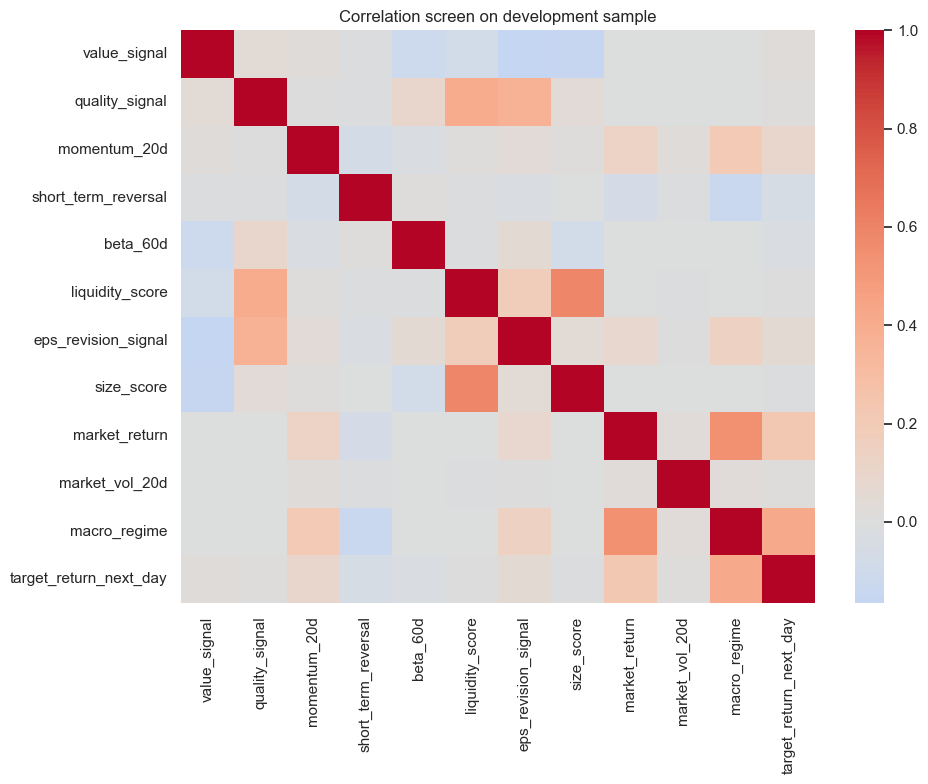

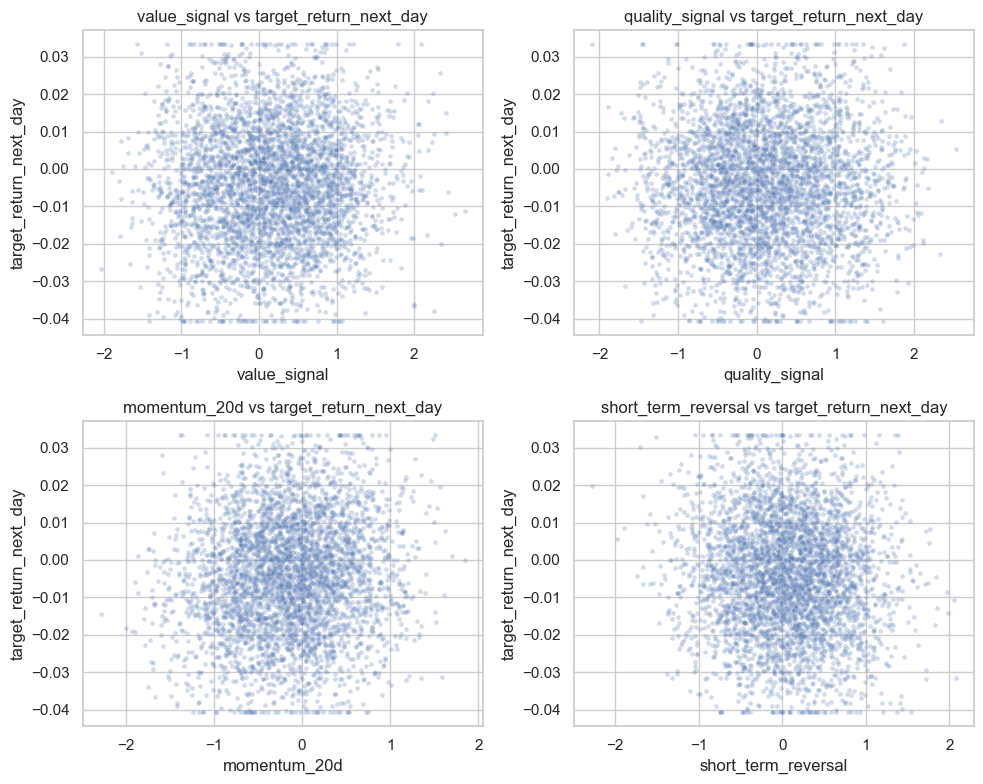

In [8]:
%matplotlib inline

pair_sample = dev_df[["return_1d", "target_return_next_day", "value_signal", "quality_signal", "momentum_20d", "short_term_reversal"]].sample(4000, random_state=0)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
plot_specs = [
    ("value_signal", "target_return_next_day"),
    ("quality_signal", "target_return_next_day"),
    ("momentum_20d", "target_return_next_day"),
    ("short_term_reversal", "target_return_next_day"),
]
for ax, (xcol, ycol) in zip(axes.flatten(), plot_specs):
    sns.scatterplot(data=pair_sample, x=xcol, y=ycol, s=12, alpha=0.25, ax=ax)
    ax.set_title(f"{xcol} vs {ycol}")
plt.tight_layout()
plt.show()

### 4.2 Are assets realistically correlated?

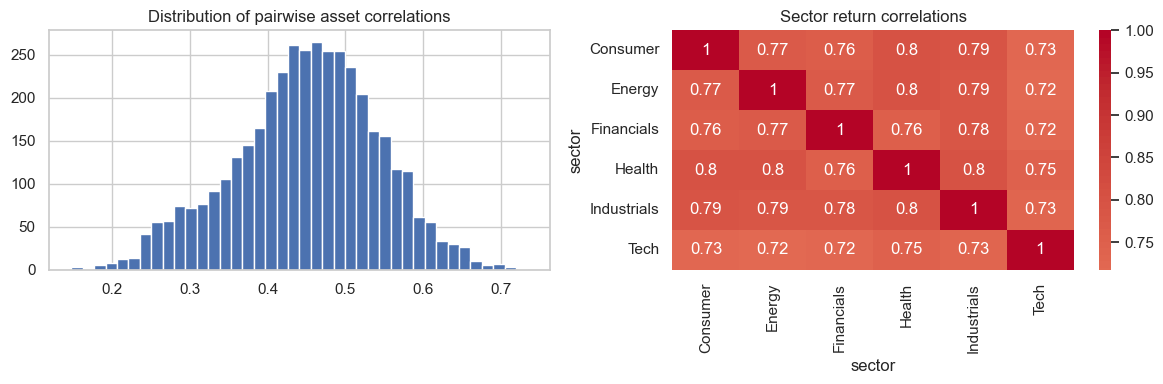

count    4005.000000
mean        0.449707
std         0.093247
min         0.147527
25%         0.392217
50%         0.454942
75%         0.512736
max         0.734223
dtype: float64

In [9]:
ret_pivot = dev_df.pivot_table(index="date", columns="asset", values="return_1d")
asset_corr = ret_pivot.corr()
upper_vals = asset_corr.where(np.triu(np.ones(asset_corr.shape), 1).astype(bool)).stack().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(upper_vals.values, bins=40)
axes[0].set_title("Distribution of pairwise asset correlations")

sector_avg = dev_df.groupby(["date", "sector"])["return_1d"].mean().unstack()
sns.heatmap(sector_avg.corr(), annot=True, cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Sector return correlations")
plt.tight_layout()
plt.show()

upper_vals.describe()

--> Pairwise correlations are meaningfully positive, and sector returns are correlated as well.

### 4.3 Cross-sectional robustness through time

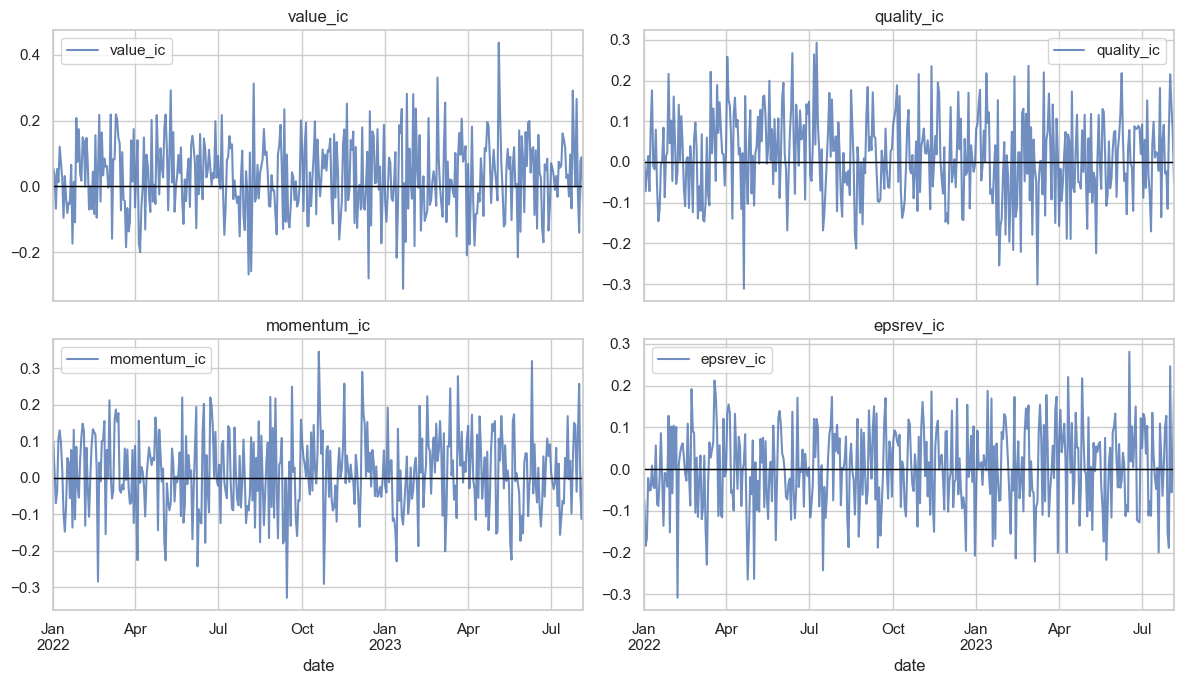

,mean,std
value_ic,0.030588,0.113216
quality_ic,0.012736,0.104079
momentum_ic,0.012371,0.106727
epsrev_ic,0.001332,0.099196


In [10]:
daily_ic = dev_df.groupby("date").apply(
    lambda x: pd.Series({
        "value_ic": x[["value_signal", "target_return_next_day"]].corr().iloc[0,1],
        "quality_ic": x[["quality_signal", "target_return_next_day"]].corr().iloc[0,1],
        "momentum_ic": x[["momentum_20d", "target_return_next_day"]].corr().iloc[0,1],
        "epsrev_ic": x[["eps_revision_signal", "target_return_next_day"]].corr().iloc[0,1],
    })
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
for ax, col in zip(axes.flatten(), ["value_ic", "quality_ic", "momentum_ic", "epsrev_ic"]):
    daily_ic.plot(x="date", y=col, ax=ax, alpha=0.8)
    ax.axhline(0, color="black", lw=1)
    ax.set_title(col)
plt.tight_layout()
plt.show()

display(daily_ic.drop(columns="date").agg(["mean", "std"]).T)

In [11]:
(daily_ic.drop(columns="date") > 0).mean()

value_ic       0.603365
quality_ic     0.564904
momentum_ic    0.528846
epsrev_ic      0.502404
dtype: float64

Value shows a clear and statistically robust signal (t-stat ≈ 5–6 over ~1.5 years), while quality and momentum exhibit weaker but still marginally significant predictive power; EPS revisions appear non-informative. Overall, signals are small relative to noise—typical for daily cross-sectional data—and require aggregation or portfolio construction to be effectively exploited.

### 4.4 Simple economic interpretation check

In [12]:
tmp = dev_df.copy()
tmp["high_vol"] = (tmp["market_vol_20d"] > tmp["market_vol_20d"].median()).astype(int)

rob_rows = []
for reg, sub in tmp.groupby("high_vol"):
    for sig in ["value_signal", "quality_signal", "momentum_20d", "eps_revision_signal"]:
        ic = sub.groupby("date").apply(lambda x: x[[sig, "target_return_next_day"]].corr().iloc[0,1]).mean()
        rob_rows.append({"high_vol": reg, "signal": sig, "avg_ic": ic})
rob_df = pd.DataFrame(rob_rows)
display(rob_df.pivot(index="signal", columns="high_vol", values="avg_ic"))

high_vol,0,1
signal,,
eps_revision_signal,0.009105,-0.006441
momentum_20d,0.004891,0.019851
quality_signal,0.015870,0.009603
value_signal,0.024986,0.036190


--> A plausible pattern here is that revisions and momentum become more informative in stressed regimes, while slow-moving value remains more stable but weaker day-to-day. I would view that as economically credible rather than suspicious.

## 5. Feature creation for modeling

In [13]:
feat_df = df.copy()
feat_df["epsrev_high_vol"] = feat_df["eps_revision_signal"] * (feat_df["market_vol_20d"] > feat_df["market_vol_20d"].median()).astype(int)
feat_df["mom_high_vol"] = feat_df["momentum_20d"] * (feat_df["market_vol_20d"] > feat_df["market_vol_20d"].median()).astype(int)
feat_df["sector_rel_value"] = feat_df["value_signal"] - feat_df.groupby(["date", "sector"])["value_signal"].transform("mean")
feat_df["sector_rel_quality"] = feat_df["quality_signal"] - feat_df.groupby(["date", "sector"])["quality_signal"].transform("mean")


Important caveat on the existing features: in a real research process I would inspect the exact feature construction logic, especially for momentum/beta/revision variables. Since this is an exploratory notebook, I am implicitly assuming they are point-in-time and causally aligned. That assumption should be audited before trusting any result.

## 6. Development split for model selection

In [14]:
unique_feat_dates = np.sort(feat_df["date"].unique())
holdout_dates_feat = unique_feat_dates[-int(len(unique_feat_dates)*0.20):]
train_dates = unique_feat_dates[:int(len(unique_feat_dates)*0.60)]
test_dates = unique_feat_dates[int(len(unique_feat_dates)*0.60):-int(len(unique_feat_dates)*0.20)]

train_df = feat_df[feat_df["date"].isin(train_dates)].copy()
dev_test_df = feat_df[feat_df["date"].isin(test_dates)].copy()
holdout_df = feat_df[feat_df["date"].isin(holdout_dates_feat)].copy()

model_features = [
    "value_signal", "quality_signal", "momentum_20d", "short_term_reversal",
    "beta_60d", "liquidity_score", "eps_revision_signal", "size_score",
    "market_return", "market_vol_20d", "macro_regime", "epsrev_high_vol",
    "mom_high_vol", "sector_rel_value", "sector_rel_quality", "sector"
]

cat_cols = ["sector"]
num_cols = [c for c in model_features if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))]), cat_cols),
])


## 7. Models

In [15]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

X_train = train_df[model_features]
y_train = train_df["target_return_next_day"]
X_dev = dev_test_df[model_features]
y_dev = dev_test_df["target_return_next_day"]

tscv = TimeSeriesSplit(n_splits=4)

# Ridge
ridge_gs = GridSearchCV(
    Pipeline([("prep", preprocess), ("model", Ridge())]),
    param_grid={"model__alpha": [2.0, 8.0, 16.0, 32.0]},
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

# Lasso
lasso_gs = GridSearchCV(
    Pipeline([("prep", preprocess), ("model", Lasso(max_iter=5000))]),
    param_grid={"model__alpha": [1e-4, 5e-4, 1e-3, 5e-3]},
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

# Elastic Net
enet_gs = GridSearchCV(
    Pipeline([("prep", preprocess), ("model", ElasticNet(max_iter=5000))]),
    param_grid={
        "model__alpha": [1e-4, 5e-4, 1e-3],
        "model__l1_ratio": [0.2, 0.5, 0.8],
    },
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

# KNN
knn_gs = GridSearchCV(
    Pipeline([("prep", preprocess), ("model", KNeighborsRegressor())]),
    param_grid={
        "model__n_neighbors": [25, 50, 100],
        "model__weights": ["uniform", "distance"],
    },
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

# Decision Tree
dt_gs = GridSearchCV(
    Pipeline([("prep", preprocess), ("model", DecisionTreeRegressor(random_state=42))]),
    param_grid={
        "model__max_depth": [3, 5, 8],
        "model__min_samples_leaf": [20, 50, 100],
    },
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

# Random Forest
rf_gs = GridSearchCV(
    Pipeline([
        ("prep", preprocess),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]),
    param_grid={
        "model__n_estimators": [200],
        "model__max_depth": [6, 8],
        "model__min_samples_leaf": [20, 50],
        "model__max_features": ["sqrt", 0.5],
    },
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

# Extra Trees
et_gs = GridSearchCV(
    Pipeline([
        ("prep", preprocess),
        ("model", ExtraTreesRegressor(random_state=42, n_jobs=-1))
    ]),
    param_grid={
        "model__n_estimators": [200],
        "model__max_depth": [6, 8],
        "model__min_samples_leaf": [20, 50],
        "model__max_features": ["sqrt", 0.5],
    },
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

# Gradient Boosting
gbr_gs = GridSearchCV(
    Pipeline([
        ("prep", preprocess),
        ("model", GradientBoostingRegressor(random_state=42))
    ]),
    param_grid={
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05],
        "model__max_depth": [2, 3],
        "model__min_samples_leaf": [20, 50],
    },
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

ridge_gs.fit(X_train, y_train)
lasso_gs.fit(X_train, y_train)
enet_gs.fit(X_train, y_train)
knn_gs.fit(X_train, y_train)
dt_gs.fit(X_train, y_train)
rf_gs.fit(X_train, y_train)
et_gs.fit(X_train, y_train)
gbr_gs.fit(X_train, y_train)

ridge_pred = ridge_gs.best_estimator_.predict(X_dev)
lasso_pred = lasso_gs.best_estimator_.predict(X_dev)
enet_pred = enet_gs.best_estimator_.predict(X_dev)
knn_pred = knn_gs.best_estimator_.predict(X_dev)
dt_pred = dt_gs.best_estimator_.predict(X_dev)
rf_pred = rf_gs.best_estimator_.predict(X_dev)
et_pred = et_gs.best_estimator_.predict(X_dev)
gbr_pred = gbr_gs.best_estimator_.predict(X_dev)

train_mean_target = y_train.mean()
naive_pred = np.repeat(train_mean_target, len(X_dev))

res = pd.DataFrame({
    "model": [
        "ridge", "lasso", "elastic_net", "knn",
        "decision_tree", "random_forest", "extra_trees",
        "gradient_boosting", "historical_mean"
    ],
    "rmse": [
        rmse(y_dev, ridge_pred),
        rmse(y_dev, lasso_pred),
        rmse(y_dev, enet_pred),
        rmse(y_dev, knn_pred),
        rmse(y_dev, dt_pred),
        rmse(y_dev, rf_pred),
        rmse(y_dev, et_pred),
        rmse(y_dev, gbr_pred),
        rmse(y_dev, naive_pred),
    ],
    "r2": [
        r2_score(y_dev, ridge_pred),
        r2_score(y_dev, lasso_pred),
        r2_score(y_dev, enet_pred),
        r2_score(y_dev, knn_pred),
        r2_score(y_dev, dt_pred),
        r2_score(y_dev, rf_pred),
        r2_score(y_dev, et_pred),
        r2_score(y_dev, gbr_pred),
        r2_score(y_dev, naive_pred),
    ],
    "cv_rmse": [
        -ridge_gs.best_score_,
        -lasso_gs.best_score_,
        -enet_gs.best_score_,
        -knn_gs.best_score_,
        -dt_gs.best_score_,
        -rf_gs.best_score_,
        -et_gs.best_score_,
        -gbr_gs.best_score_,
        np.nan,
    ],
}).sort_values("rmse")

display(res)

print("Best Ridge params:", ridge_gs.best_params_)
print("Best Lasso params:", lasso_gs.best_params_)
print("Best Elastic Net params:", enet_gs.best_params_)
print("Best KNN params:", knn_gs.best_params_)
print("Best Decision Tree params:", dt_gs.best_params_)
print("Best Random Forest params:", rf_gs.best_params_)
print("Best Extra Trees params:", et_gs.best_params_)
print("Best Gradient Boosting params:", gbr_gs.best_params_)

/Users/zarkamaxime/Library/CloudStorage/OneDrive-TheBostonConsultingGroup,Inc/Desktop/SquareP/Jupyternotebooks/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/zarkamaxime/Library/CloudStorage/OneDrive-TheBostonConsultingGroup,Inc/Desktop/SquareP/Jupyternotebooks/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/zarkamaxime/Library/CloudStorage/OneDrive-TheBostonConsultingGroup,Inc/Desktop/SquareP/Jupyternotebooks/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklear

,model,rmse,r2,cv_rmse
1,lasso,0.014074,0.230788,0.014059
2,elastic_net,0.014087,0.229333,0.014057
0,ridge,0.014095,0.228422,0.014053
6,extra_trees,0.014272,0.208917,0.013606
5,random_forest,0.014367,0.198328,0.012799
7,gradient_boosting,0.014476,0.186147,0.012865
3,knn,0.014590,0.173341,0.014282
4,decision_tree,0.015248,0.097082,0.012695
8,historical_mean,0.016168,-0.015224,NaN


Best Ridge params: {'model__alpha': 2.0}
Best Lasso params: {'model__alpha': 0.0001}
Best Elastic Net params: {'model__alpha': 0.001, 'model__l1_ratio': 0.2}
Best KNN params: {'model__n_neighbors': 100, 'model__weights': 'distance'}
Best Decision Tree params: {'model__max_depth': 8, 'model__min_samples_leaf': 50}
Best Random Forest params: {'model__max_depth': 8, 'model__max_features': 0.5, 'model__min_samples_leaf': 20, 'model__n_estimators': 200}
Best Extra Trees params: {'model__max_depth': 8, 'model__max_features': 0.5, 'model__min_samples_leaf': 20, 'model__n_estimators': 200}
Best Gradient Boosting params: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_samples_leaf': 20, 'model__n_estimators': 200}


Before over-interpreting the learned model, it is useful to check whether most of the ranking value already comes from a small set of economically sensible signals. 

--> Comparing an a 1-signal based prediction, an equal-weight standardized blend and the full Ridge helps distinguish three effects: signal choice, weight estimation, and potential dilution from adding broader features.

In [17]:
# Helper function 

def daily_rank_ic(frame, pred_col, target_col="target_return_next_day"):
    vals = frame.groupby("date").apply(
        lambda x: x[[pred_col, target_col]].corr(method="spearman").iloc[0, 1]
    )
    return vals.dropna()

In [18]:
score_df = dev_test_df[["date", "asset", "sector", "target_return_next_day"]].copy()

score_df["value_signal"] = dev_test_df["value_signal"]
score_df["sector_rel_value"] = dev_test_df["sector_rel_value"]

score_df["ridge"] = ridge_gs.best_estimator_.predict(X_dev)
score_df["lasso"] = lasso_gs.best_estimator_.predict(X_dev)
score_df["elastic_net"] = enet_gs.best_estimator_.predict(X_dev)
score_df["knn"] = knn_gs.best_estimator_.predict(X_dev)
score_df["decision_tree"] = dt_gs.best_estimator_.predict(X_dev)
score_df["random_forest"] = rf_gs.best_estimator_.predict(X_dev)
score_df["extra_trees"] = et_gs.best_estimator_.predict(X_dev)
score_df["gradient_boosting"] = gbr_gs.best_estimator_.predict(X_dev)

models_to_compare = [
    "value_signal",
    "sector_rel_value",
    "ridge",
    "lasso",
    "elastic_net",
    "knn",
    "decision_tree",
    "random_forest",
    "extra_trees",
    "gradient_boosting",
]

rows = []
for model_name in models_to_compare:
    ic = daily_rank_ic(score_df, model_name)
    rows.append({
        "model": model_name,
        "mean_daily_spearman_ic": ic.mean(),
        "std_daily_spearman_ic": ic.std(),
        "tstat_ic": ic.mean() / (ic.std() / np.sqrt(len(ic))) if ic.std() > 0 else np.nan,
        "n_days": len(ic),
    })

ic_summary_df = pd.DataFrame(rows).sort_values("mean_daily_spearman_ic", ascending=False).reset_index(drop=True)
display(ic_summary_df)

,model,mean_daily_spearman_ic,std_daily_spearman_ic,tstat_ic,n_days
0,extra_trees,0.054460,0.149385,3.735669,105
1,gradient_boosting,0.053608,0.127432,4.310681,105
2,random_forest,0.044992,0.137956,3.341846,105
3,decision_tree,0.037242,0.152927,1.481314,37
4,lasso,0.034706,0.141608,2.511410,105
5,elastic_net,0.033402,0.144784,2.364010,105
6,value_signal,0.029483,0.108261,2.790613,105
7,knn,0.028347,0.116786,2.487234,105
8,sector_rel_value,0.024944,0.098654,2.590905,105
9,ridge,0.010243,0.157392,0.666854,105


### ALTERNATIVE ALL TOGETHER

In [19]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

X_train = train_df[model_features]
y_train = train_df["target_return_next_day"]
X_dev = dev_test_df[model_features]
y_dev = dev_test_df["target_return_next_day"]

tscv = TimeSeriesSplit(n_splits=4)

model_specs = [
    {
        "name": "ridge",
        "search": GridSearchCV(
            Pipeline([("prep", preprocess), ("model", Ridge())]),
            param_grid={"model__alpha": [2.0, 8.0, 16.0, 32.0]},
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            n_jobs=-1,
            refit=True,
        ),
    },
    {
        "name": "lasso",
        "search": GridSearchCV(
            Pipeline([("prep", preprocess), ("model", Lasso(max_iter=20000))]),
            param_grid={"model__alpha": [5e-4, 1e-3, 5e-3, 1e-2]},
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            n_jobs=-1,
            refit=True,
        ),
    },
    {
        "name": "elastic_net",
        "search": GridSearchCV(
            Pipeline([("prep", preprocess), ("model", ElasticNet(max_iter=20000))]),
            param_grid={
                "model__alpha": [5e-4, 1e-3, 5e-3],
                "model__l1_ratio": [0.2, 0.5, 0.8],
            },
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            n_jobs=-1,
            refit=True,
        ),
    },
    {
        "name": "knn",
        "search": GridSearchCV(
            Pipeline([("prep", preprocess), ("model", KNeighborsRegressor())]),
            param_grid={
                "model__n_neighbors": [25, 50, 100],
                "model__weights": ["uniform", "distance"],
            },
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            n_jobs=-1,
            refit=True,
        ),
    },
    {
        "name": "decision_tree",
        "search": GridSearchCV(
            Pipeline([("prep", preprocess), ("model", DecisionTreeRegressor(random_state=42))]),
            param_grid={
                "model__max_depth": [3, 5, 8],
                "model__min_samples_leaf": [20, 50, 100],
            },
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            n_jobs=-1,
            refit=True,
        ),
    },
    {
        "name": "random_forest",
        "search": GridSearchCV(
            Pipeline([("prep", preprocess), ("model", RandomForestRegressor(random_state=42, n_jobs=-1))]),
            param_grid={
                "model__n_estimators": [200],
                "model__max_depth": [6, 8],
                "model__min_samples_leaf": [20, 50],
                "model__max_features": ["sqrt", 0.5],
            },
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            n_jobs=-1,
            refit=True,
        ),
    },
    {
        "name": "extra_trees",
        "search": GridSearchCV(
            Pipeline([("prep", preprocess), ("model", ExtraTreesRegressor(random_state=42, n_jobs=-1))]),
            param_grid={
                "model__n_estimators": [200],
                "model__max_depth": [6, 8],
                "model__min_samples_leaf": [20, 50],
                "model__max_features": ["sqrt", 0.5],
            },
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            n_jobs=-1,
            refit=True,
        ),
    },
    {
        "name": "gradient_boosting",
        "search": GridSearchCV(
            Pipeline([("prep", preprocess), ("model", GradientBoostingRegressor(random_state=42))]),
            param_grid={
                "model__n_estimators": [100, 200],
                "model__learning_rate": [0.03, 0.05],
                "model__max_depth": [2, 3],
                "model__min_samples_leaf": [20, 50],
            },
            scoring="neg_root_mean_squared_error",
            cv=tscv,
            n_jobs=-1,
            refit=True,
        ),
    },
]

score_df = dev_test_df[["date", "asset", "sector", "target_return_next_day"]].copy()
score_df["value_signal"] = dev_test_df["value_signal"]
score_df["sector_rel_value"] = dev_test_df["sector_rel_value"]

rows = []
best_searches = {}

for spec in model_specs:
    name = spec["name"]
    gs = spec["search"]

    gs.fit(X_train, y_train)
    pred = gs.best_estimator_.predict(X_dev)

    best_searches[name] = gs
    score_df[name] = pred

    ic = daily_rank_ic(score_df, name)

    rows.append({
        "model": name,
        "best_params": str(gs.best_params_),
        "rmse": rmse(y_dev, pred),
        "r2": r2_score(y_dev, pred),
        "cv_rmse": -gs.best_score_,
        "mean_daily_spearman_ic": ic.mean(),
        "std_daily_spearman_ic": ic.std(),
        "tstat_ic": ic.mean() / (ic.std() / np.sqrt(len(ic))) if ic.std() > 0 else np.nan,
        "n_days": len(ic),
    })

for signal_name in ["value_signal", "sector_rel_value"]:
    ic = daily_rank_ic(score_df, signal_name)
    rows.append({
        "model": signal_name,
        "best_params": "",
        "rmse": np.nan,
        "r2": np.nan,
        "cv_rmse": np.nan,
        "mean_daily_spearman_ic": ic.mean(),
        "std_daily_spearman_ic": ic.std(),
        "tstat_ic": ic.mean() / (ic.std() / np.sqrt(len(ic))) if ic.std() > 0 else np.nan,
        "n_days": len(ic),
    })

summary_df = pd.DataFrame(rows).sort_values("mean_daily_spearman_ic", ascending=False).reset_index(drop=True)
display(summary_df)

ridge_gs = best_searches["ridge"]
rf_gs = best_searches["random_forest"]

,model,best_params,rmse,r2,cv_rmse,mean_daily_spearman_ic,std_daily_spearman_ic,tstat_ic,n_days
0,extra_trees,"{'model__max_depth': 8, 'model__max_features':...",0.014272,0.208917,0.013606,0.054460,0.149385,3.735669,105
1,gradient_boosting,"{'model__learning_rate': 0.05, 'model__max_dep...",0.014476,0.186147,0.012865,0.053608,0.127432,4.310681,105
2,random_forest,"{'model__max_depth': 8, 'model__max_features':...",0.014367,0.198328,0.012799,0.044992,0.137956,3.341846,105
3,decision_tree,"{'model__max_depth': 8, 'model__min_samples_le...",0.015248,0.097082,0.012695,0.037242,0.152927,1.481314,37
4,elastic_net,"{'model__alpha': 0.001, 'model__l1_ratio': 0.2}",0.014087,0.229333,0.014057,0.033402,0.144784,2.364010,105
5,value_signal,,NaN,NaN,NaN,0.029483,0.108261,2.790613,105
6,knn,"{'model__n_neighbors': 100, 'model__weights': ...",0.014590,0.173341,0.014282,0.028347,0.116786,2.487234,105
7,sector_rel_value,,NaN,NaN,NaN,0.024944,0.098654,2.590905,105
8,ridge,{'model__alpha': 2.0},0.014095,0.228422,0.014053,0.010243,0.157392,0.666854,105
9,lasso,{'model__alpha': 0.0005},0.014130,0.224582,0.014067,NaN,NaN,NaN,0


## 8. Walk forward IC on RF and Ridge

In [28]:
from sklearn.base import clone

wf_df = pd.concat([train_df, dev_test_df], axis=0).sort_values("date").copy()
wf_dates = np.array(sorted(wf_df["date"].unique()))
date_blocks = np.array_split(wf_dates, 6)

walk_rows = []

for i in range(1, len(date_blocks)):
    train_dates_wf = np.concatenate(date_blocks[:i])
    test_dates_wf = date_blocks[i]

    wf_train = wf_df[wf_df["date"].isin(train_dates_wf)].copy()
    wf_test = wf_df[wf_df["date"].isin(test_dates_wf)].copy()

    X_train_wf = wf_train[model_features]
    y_train_wf = wf_train["target_return_next_day"]
    X_test_wf = wf_test[model_features]

    ridge_wf = clone(ridge_gs.best_estimator_)
    rf_wf = clone(rf_gs.best_estimator_)

    ridge_wf.fit(X_train_wf, y_train_wf)
    rf_wf.fit(X_train_wf, y_train_wf)

    wf_scores = wf_test[["date", "asset", "sector", "target_return_next_day"]].copy()
    wf_scores["ridge"] = ridge_wf.predict(X_test_wf)
    wf_scores["random_forest"] = rf_wf.predict(X_test_wf)
    wf_scores["sector_rel_value"] = wf_test["sector_rel_value"]

    for model_name in ["random_forest", "ridge", "sector_rel_value"]:
        ic = daily_rank_ic(wf_scores, model_name)
        walk_rows.append({
            "period": i,
            "start_date": test_dates_wf.min(),
            "end_date": test_dates_wf.max(),
            "model": model_name,
            "mean_daily_spearman_ic": ic.mean(),
            "tstat_ic": ic.mean() / (ic.std() / np.sqrt(len(ic))) if ic.std() > 0 else np.nan,
            "n_days": len(ic),
        })

walk_df = pd.DataFrame(walk_rows)
display(walk_df)

pivot_ic = walk_df.pivot(index="period", columns="model", values="mean_daily_spearman_ic")
display(pivot_ic)

,period,start_date,end_date,model,mean_daily_spearman_ic,tstat_ic,n_days
0,1,2022-04-11,2022-07-15,random_forest,-0.002050,-0.117335,70
1,1,2022-04-11,2022-07-15,ridge,0.011671,0.536834,70
2,1,2022-04-11,2022-07-15,sector_rel_value,0.048310,4.340719,70
3,2,2022-07-18,2022-10-20,random_forest,0.017471,1.144852,69
4,2,2022-07-18,2022-10-20,ridge,-0.011168,-0.579248,69
5,2,2022-07-18,2022-10-20,sector_rel_value,0.014542,1.166850,69
6,3,2022-10-21,2023-01-25,random_forest,0.030124,2.067029,69
7,3,2022-10-21,2023-01-25,ridge,-0.000632,-0.031029,69
8,3,2022-10-21,2023-01-25,sector_rel_value,0.018713,1.406477,69
9,4,2023-01-26,2023-05-02,random_forest,0.094126,6.248213,69


model,random_forest,ridge,sector_rel_value
period,,,
1,-0.002050,0.011671,0.048310
2,0.017471,-0.011168,0.014542
3,0.030124,-0.000632,0.018713
4,0.094126,0.019601,0.023784
5,0.054553,0.022254,0.029623


The walk-forward results are broadly consistent with the earlier diagnostics. Sector-relative value is the most stable signal across periods, remaining positive throughout, while the random forest is more variable but becomes the strongest model in the later periods. Ridge remains weaker and less consistent.

My reading is that sector-relative value offers the most robust baseline, whereas the random forest remains the more promising but less stable model. This reinforces the idea that the random forest may be capturing meaningful structure, but in a way that is more sensitive to sample size or market regime.

## 9. Translate predictions into long/short portfolio -> VERSION SECTOR NEUTRAL 

,strategy,mean_daily_ret,daily_vol,annualized_sharpe,avg_turnover
3,lasso_sector_neutral,0.002789,0.011182,3.958878,0.009524
9,gradient_boosting_sector_neutral,0.000626,0.002517,3.948887,1.399272
4,elastic_net_sector_neutral,0.000208,0.002858,1.156871,0.790741
6,decision_tree_sector_neutral,0.000553,0.008326,1.054546,0.272383
2,ridge_sector_neutral,-0.000010,0.002586,-0.062272,1.023280
8,extra_trees_sector_neutral,-0.000044,0.002703,-0.255755,1.502116
7,random_forest_sector_neutral,-0.000048,0.002438,-0.310224,1.529101
0,value_signal_sector_neutral,-0.000083,0.002619,-0.501227,1.048148
1,sector_rel_value_sector_neutral,-0.000083,0.002619,-0.501227,1.048148
5,knn_sector_neutral,-0.000114,0.002528,-0.717825,1.570899


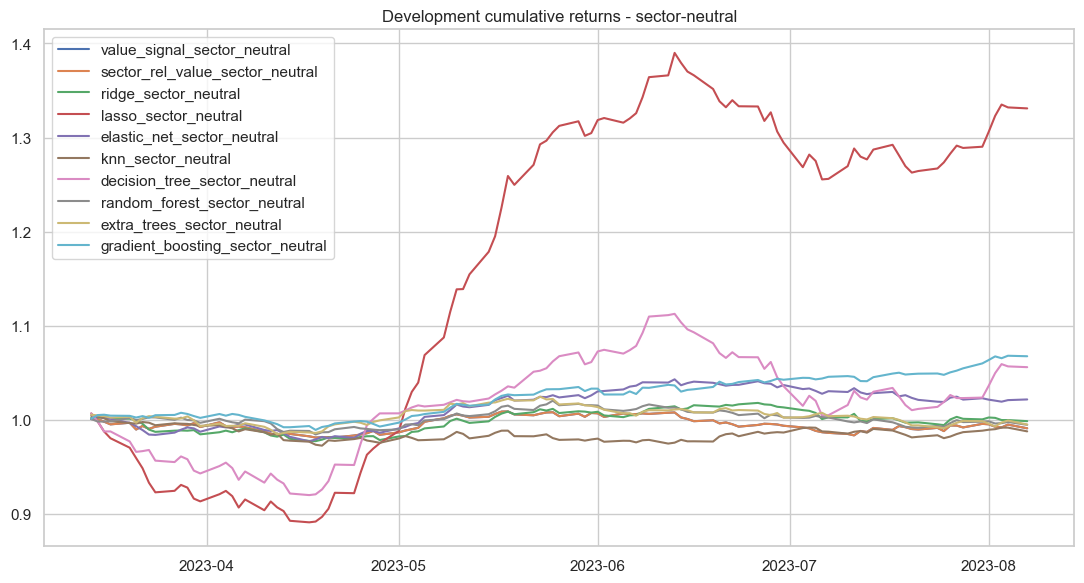

In [21]:
def run_sector_neutral_equal_weight_backtest(frame, score_col, target_col="target_return_next_day", q=0.10, cost_bps=5):
    out = []
    prev_w = None

    for d, g in frame.groupby("date"):
        weights = pd.Series(0.0, index=g["asset"].values)

        for _, sg in g.groupby("sector"):
            score = sg.set_index("asset")[score_col]
            lo = score.quantile(q)
            hi = score.quantile(1 - q)

            long_assets = score.index[score >= hi]
            short_assets = score.index[score <= lo]

            if len(long_assets) > 0:
                weights.loc[long_assets] = 1 / len(long_assets)
            if len(short_assets) > 0:
                weights.loc[short_assets] = -1 / len(short_assets)

        weights = weights / weights.abs().sum()

        if prev_w is None:
            turnover = weights.abs().sum()
        else:
            all_assets = weights.index.union(prev_w.index)
            turnover = (
                weights.reindex(all_assets).fillna(0) - prev_w.reindex(all_assets).fillna(0)
            ).abs().sum()

        asset_returns = g.set_index("asset")[target_col]
        ret = (weights.reindex(asset_returns.index).fillna(0) * asset_returns).sum() - (cost_bps / 10000.0) * turnover

        out.append({"date": d, "strategy_return": ret, "turnover": turnover})
        prev_w = weights.copy()

    return pd.DataFrame(out)


strategies = {
    "value_signal_sector_neutral": "value_signal",
    "sector_rel_value_sector_neutral": "sector_rel_value",
    "ridge_sector_neutral": "ridge",
    "lasso_sector_neutral": "lasso",
    "elastic_net_sector_neutral": "elastic_net",
    "knn_sector_neutral": "knn",
    "decision_tree_sector_neutral": "decision_tree",
    "random_forest_sector_neutral": "random_forest",
    "extra_trees_sector_neutral": "extra_trees",
    "gradient_boosting_sector_neutral": "gradient_boosting",
}

results = []
all_bt = {}

for strategy_name, score_col in strategies.items():
    bt = run_sector_neutral_equal_weight_backtest(
        score_df,
        score_col=score_col,
        q=0.10,
        cost_bps=5,
    )
    all_bt[strategy_name] = bt

    results.append({
        "strategy": strategy_name,
        "mean_daily_ret": bt["strategy_return"].mean(),
        "daily_vol": bt["strategy_return"].std(),
        "annualized_sharpe": np.sqrt(252) * bt["strategy_return"].mean() / bt["strategy_return"].std(),
        "avg_turnover": bt["turnover"].mean(),
    })

summary_df = pd.DataFrame(results).sort_values("annualized_sharpe", ascending=False)
display(summary_df)

plt.figure(figsize=(11, 6))
for strategy_name, bt in all_bt.items():
    plt.plot(bt["date"], (1 + bt["strategy_return"]).cumprod(), label=strategy_name)
plt.legend()
plt.title("Development cumulative returns - sector-neutral")
plt.tight_layout()
plt.show()

In [22]:
pd.Series(lasso_gs.best_estimator_.named_steps["model"].coef_, 
          index=lasso_gs.best_estimator_.named_steps["prep"].get_feature_names_out()).sort_values(key=np.abs, ascending=False).head(20)

num__macro_regime           0.005808
num__beta_60d              -0.000345
num__value_signal           0.000250
num__quality_signal         0.000062
num__mom_high_vol           0.000054
num__short_term_reversal    0.000000
cat__sector_Industrials    -0.000000
cat__sector_Health          0.000000
cat__sector_Financials      0.000000
cat__sector_Energy          0.000000
num__sector_rel_quality     0.000000
num__sector_rel_value       0.000000
num__epsrev_high_vol       -0.000000
num__momentum_20d           0.000000
num__market_vol_20d         0.000000
num__market_return         -0.000000
num__size_score            -0.000000
num__eps_revision_signal   -0.000000
num__liquidity_score        0.000000
cat__sector_Tech           -0.000000
dtype: float64

## 10. Final holdout evaluation --> VERSION SECTOR NEUTRAL WITH ALL POSSIBLE STRATS (NOT BEST PRACTICE)

In [24]:
def run_equal_weight_backtest(frame, score_col, target_col="target_return_next_day", q=0.10, cost_bps=5):
    out = []
    prev_w = None

    for d, g in frame.groupby("date"):
        score = g.set_index("asset")[score_col]
        lo = score.quantile(q)
        hi = score.quantile(1 - q)

        long_assets = score.index[score >= hi]
        short_assets = score.index[score <= lo]

        weights = pd.Series(0.0, index=score.index)
        if len(long_assets) > 0:
            weights.loc[long_assets] = 1 / len(long_assets)
        if len(short_assets) > 0:
            weights.loc[short_assets] = -1 / len(short_assets)

        weights = weights / weights.abs().sum()

        if prev_w is None:
            turnover = weights.abs().sum()
        else:
            all_assets = weights.index.union(prev_w.index)
            turnover = (
                weights.reindex(all_assets).fillna(0) - prev_w.reindex(all_assets).fillna(0)
            ).abs().sum()

        asset_returns = g.set_index("asset")[target_col]
        ret = (weights * asset_returns).sum() - (cost_bps / 10000.0) * turnover

        out.append({"date": d, "strategy_return": ret, "turnover": turnover})
        prev_w = weights.copy()

    return pd.DataFrame(out)


holdout_scores = holdout_df[["date", "asset", "sector", "target_return_next_day"]].copy()

holdout_scores["value_signal"] = holdout_df["value_signal"]
holdout_scores["sector_rel_value"] = holdout_df["sector_rel_value"]

holdout_scores["ridge"] = ridge_gs.best_estimator_.predict(holdout_df[model_features])
holdout_scores["lasso"] = lasso_gs.best_estimator_.predict(holdout_df[model_features])
holdout_scores["elastic_net"] = enet_gs.best_estimator_.predict(holdout_df[model_features])
holdout_scores["knn"] = knn_gs.best_estimator_.predict(holdout_df[model_features])
holdout_scores["decision_tree"] = dt_gs.best_estimator_.predict(holdout_df[model_features])
holdout_scores["random_forest"] = rf_gs.best_estimator_.predict(holdout_df[model_features])
holdout_scores["extra_trees"] = et_gs.best_estimator_.predict(holdout_df[model_features])
holdout_scores["gradient_boosting"] = gbr_gs.best_estimator_.predict(holdout_df[model_features])

models_to_compare = [
    "value_signal",
    "sector_rel_value",
    "ridge",
    "lasso",
    "elastic_net",
    "knn",
    "decision_tree",
    "random_forest",
    "extra_trees",
    "gradient_boosting",
]

rows = []
for col in models_to_compare:
    ic = daily_rank_ic(holdout_scores, col)
    bt = run_equal_weight_backtest(
        holdout_scores,
        score_col=col,
        q=0.10,
        cost_bps=5,
    )

    rows.append({
        "strategy": col,
        "mean_holdout_ic": ic.mean(),
        "holdout_ic_tstat": ic.mean() / (ic.std() / np.sqrt(len(ic))) if ic.std() > 0 else np.nan,
        "holdout_annualized_sharpe": np.sqrt(252) * bt["strategy_return"].mean() / bt["strategy_return"].std(),
        "holdout_avg_turnover": bt["turnover"].mean(),
    })

holdout_summary_df = pd.DataFrame(rows).sort_values("mean_holdout_ic", ascending=False).reset_index(drop=True)
display(holdout_summary_df)

,strategy,mean_holdout_ic,holdout_ic_tstat,holdout_annualized_sharpe,holdout_avg_turnover
0,decision_tree,0.076381,1.821731,5.364820,0.266882
1,ridge,0.045710,3.070088,0.622248,1.278317
2,gradient_boosting,0.045682,4.628587,0.836803,1.383310
3,lasso,0.035121,3.024504,0.608852,0.973031
4,extra_trees,0.033584,2.817827,0.729330,1.445523
5,value_signal,0.032681,2.969088,0.258066,1.039914
6,elastic_net,0.032649,2.774353,1.056359,0.955771
7,sector_rel_value,0.025534,2.577262,-0.018345,1.023732
8,random_forest,0.023117,2.267535,-2.966979,1.502697
9,knn,0.005926,0.656839,-2.765801,1.647249


## SIGNIFICANCE

In [33]:
import statsmodels.api as sm
from scipy import stats

models_to_compare = [
    "decision_tree",
    "ridge",
    "gradient_boosting",
    "lasso",
    "extra_trees",
    "value_signal",
    "elastic_net",
    "sector_rel_value",
    "random_forest",
    "knn",
]

rows = []
n_tests = len(models_to_compare)

for col in models_to_compare:
    bt = run_equal_weight_backtest(
        holdout_scores,
        score_col=col,
        q=0.10,
        cost_bps=5,
    )

    ret = bt["strategy_return"].dropna().reset_index(drop=True)

    mean_daily_ret = ret.mean()
    daily_vol = ret.std()
    n = len(ret)

    annualized_sharpe = np.sqrt(252) * mean_daily_ret / daily_vol if daily_vol > 0 else np.nan

    # IID t-stat / p-value for mean return
    se_iid = daily_vol / np.sqrt(n) if n > 1 and daily_vol > 0 else np.nan
    iid_tstat = mean_daily_ret / se_iid if se_iid > 0 else np.nan
    p_raw_iid = 2 * (1 - stats.t.cdf(abs(iid_tstat), df=n - 1)) if n > 1 and np.isfinite(iid_tstat) else np.nan

    # HAC / Newey-West t-stat / p-value for mean return
    X = np.ones(n)
    ols = sm.OLS(ret, X).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    hac_tstat = float(np.asarray(ols.tvalues)[0])
    p_raw_hac = float(np.asarray(ols.pvalues)[0])
    p_bonf_hac = min(p_raw_hac * n_tests, 1.0)

    rows.append({
        "strategy": col,
        "mean_daily_ret": mean_daily_ret,
        "daily_vol": daily_vol,
        "annualized_sharpe": annualized_sharpe,
        "iid_tstat_mean_ret": iid_tstat,
        "pvalue_raw_iid": p_raw_iid,
        "hac_tstat_mean_ret": hac_tstat,
        "pvalue_raw_hac": p_raw_hac,
        "pvalue_bonferroni_hac": p_bonf_hac,
        "avg_turnover": bt["turnover"].mean(),
        "n_days": n,
    })

pval_summary_df = pd.DataFrame(rows).sort_values("pvalue_bonferroni_hac").reset_index(drop=True)
display(pval_summary_df)

,strategy,mean_daily_ret,daily_vol,annualized_sharpe,iid_tstat_mean_ret,pvalue_raw_iid,hac_tstat_mean_ret,pvalue_raw_hac,pvalue_bonferroni_hac,avg_turnover,n_days
0,decision_tree,0.003069,0.009081,5.364820,3.429837,0.000873,2.447254,0.014395,0.143949,0.266882,103
1,knn,-0.000464,0.002662,-2.765801,-1.768232,0.080012,-1.868787,0.061652,0.616524,1.647249,103
2,random_forest,-0.000570,0.003047,-2.966979,-1.896849,0.060677,-1.721625,0.085138,0.851375,1.502697,103
3,ridge,0.000127,0.003252,0.622248,0.397815,0.691598,0.386063,0.699450,1.000000,1.278317,103
4,gradient_boosting,0.000145,0.002744,0.836803,0.534985,0.593825,0.499598,0.617358,1.000000,1.383310,103
5,lasso,0.000118,0.003078,0.608852,0.389251,0.697902,0.358151,0.720230,1.000000,0.973031,103
6,extra_trees,0.000141,0.003075,0.729330,0.466276,0.642013,0.419165,0.675095,1.000000,1.445523,103
7,value_signal,0.000043,0.002655,0.258066,0.164987,0.869281,0.157404,0.874927,1.000000,1.039914,103
8,elastic_net,0.000203,0.003054,1.056359,0.675352,0.500980,0.572130,0.567234,1.000000,0.955771,103
9,sector_rel_value,-0.000003,0.002485,-0.018345,-0.011728,0.990665,-0.009701,0.992260,1.000000,1.023732,103


## WALK FORWARD ON STRAT

,period,start_date,end_date,model,annualized_sharpe,avg_turnover,n_days
0,1,2022-04-11,2022-07-15,ridge,-0.261367,1.412302,70
1,1,2022-04-11,2022-07-15,sector_rel_value,2.487908,1.071825,70
2,2,2022-07-18,2022-10-20,ridge,-0.941977,1.141707,69
3,2,2022-07-18,2022-10-20,sector_rel_value,-1.630419,1.099436,69
4,3,2022-10-21,2023-01-25,ridge,-0.431315,1.233494,69
5,3,2022-10-21,2023-01-25,sector_rel_value,0.203750,1.034219,69
6,4,2023-01-26,2023-05-02,ridge,-0.408710,1.127617,69
7,4,2023-01-26,2023-05-02,sector_rel_value,0.477626,1.059984,69
8,5,2023-05-03,2023-08-07,ridge,0.297039,1.067230,69
9,5,2023-05-03,2023-08-07,sector_rel_value,0.242876,1.055153,69


model,ridge,sector_rel_value
period,,
1,-0.261367,2.487908
2,-0.941977,-1.630419
3,-0.431315,0.203750
4,-0.408710,0.477626
5,0.297039,0.242876


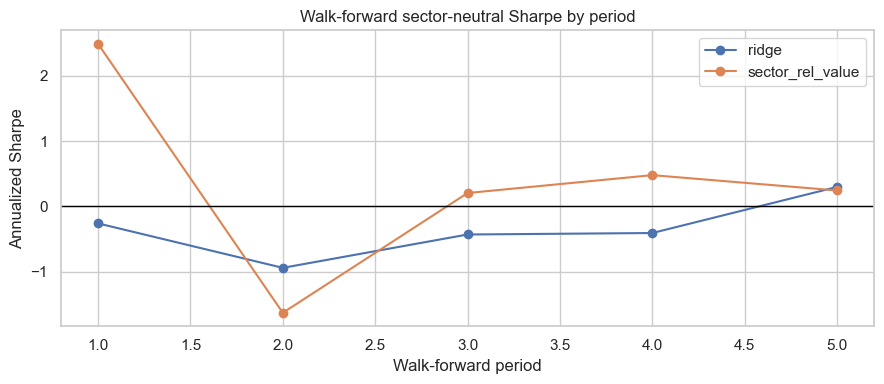

In [29]:
from sklearn.base import clone

wf_df = pd.concat([train_df, dev_test_df], axis=0).sort_values("date").copy()
wf_dates = np.array(sorted(wf_df["date"].unique()))
date_blocks = np.array_split(wf_dates, 6)

walk_rows = []

for i in range(1, len(date_blocks)):
    train_dates_wf = np.concatenate(date_blocks[:i])
    test_dates_wf = date_blocks[i]

    wf_train = wf_df[wf_df["date"].isin(train_dates_wf)].copy()
    wf_test = wf_df[wf_df["date"].isin(test_dates_wf)].copy()

    X_train_wf = wf_train[model_features]
    y_train_wf = wf_train["target_return_next_day"]
    X_test_wf = wf_test[model_features]

    ridge_wf = clone(ridge_gs.best_estimator_)
    ridge_wf.fit(X_train_wf, y_train_wf)

    wf_scores = wf_test[["date", "asset", "sector", "target_return_next_day"]].copy()
    wf_scores["ridge"] = ridge_wf.predict(X_test_wf)
    wf_scores["sector_rel_value"] = wf_test["sector_rel_value"]

    for model_name in ["ridge", "sector_rel_value"]:
        bt = run_sector_neutral_equal_weight_backtest(
            wf_scores,
            score_col=model_name,
            q=0.10,
            cost_bps=5,
        )
        walk_rows.append({
            "period": i,
            "start_date": test_dates_wf.min(),
            "end_date": test_dates_wf.max(),
            "model": model_name,
            "annualized_sharpe": np.sqrt(252) * bt["strategy_return"].mean() / bt["strategy_return"].std(),
            "avg_turnover": bt["turnover"].mean(),
            "n_days": len(bt),
        })

walk_sharpe_df = pd.DataFrame(walk_rows)
display(walk_sharpe_df)

pivot_sharpe = walk_sharpe_df.pivot(index="period", columns="model", values="annualized_sharpe")
display(pivot_sharpe)

plt.figure(figsize=(9, 4))
for model_name in pivot_sharpe.columns:
    plt.plot(pivot_sharpe.index, pivot_sharpe[model_name], marker="o", label=model_name)
plt.axhline(0, color="black", lw=1)
plt.xlabel("Walk-forward period")
plt.ylabel("Annualized Sharpe")
plt.title("Walk-forward sector-neutral Sharpe by period")
plt.legend()
plt.tight_layout()
plt.show()

The walk-forward sector-neutral Sharpe profile remains more favorable for sector-relative value than for Ridge. Ridge is slightly more stable, but mostly around or below zero, while sector-relative value shows more variability yet delivers better performance in most of the later periods.

My reading is that Ridge does not add enough economic value on top of the simpler linear benchmark. At this stage, sector-relative value still looks like the more credible linear reference strategy.